### KNN Regression으로 50cm 생선의 무게 예측 

In [2]:
import numpy as np

In [3]:
fish_length = np.array(
    [8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0, 
     21.0, 21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5, 
     22.5, 22.7, 23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5, 
     27.3, 27.5, 27.5, 27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0, 
     36.5, 36.0, 37.0, 37.0, 39.0, 39.0, 39.0, 40.0, 40.0, 40.0, 
     40.0, 42.0, 43.0, 43.0, 43.5, 44.0]
     )
fish_weight = np.array(
    [5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 
     110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 
     130.0, 150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 
     197.0, 218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 
     514.0, 556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 
     820.0, 850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 
     1000.0, 1000.0]
     )

In [9]:
from sklearn.model_selection import train_test_split

In [8]:
train_input, test_input, train_target, test_target = \
    train_test_split(
        fish_length,
        fish_weight,
        random_state = 42   
    )

In [ ]:
# 1열로 구성된 배열로 구성
train_input = train_input.reshape(-1, 1)
test_input = test_input.reshape(-1, 1)

#### kNN Regression Model

In [13]:
from sklearn.neighbors import KNeighborsRegressor

In [14]:
# 이웃의 갯수를 3으로 선택
knr = KNeighborsRegressor(n_neighbors=3)
knr.fit(train_input, train_target)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


#### 길이가 50cm인 생선의 무게 예측

In [16]:
knr.predict([[50]])

array([1033.33333333])

#### 기존 데이터로 무게 확인

In [19]:
for i, v in list(enumerate(train_target)):
    if v == train_target.max():
        print(train_input[i], v)

[43.] 1100.0
[42.] 1100.0


> 기존 데이터에서는 길이가 42, 43cm인 경우에 무게가 1.1Kg이 나왔는데,              
50cm인 경우에 1Kg이 좀 넘게 나왔다.??

### 산점도로 이웃을 구해서 확인해 보자

In [20]:
import matplotlib.pyplot as plt

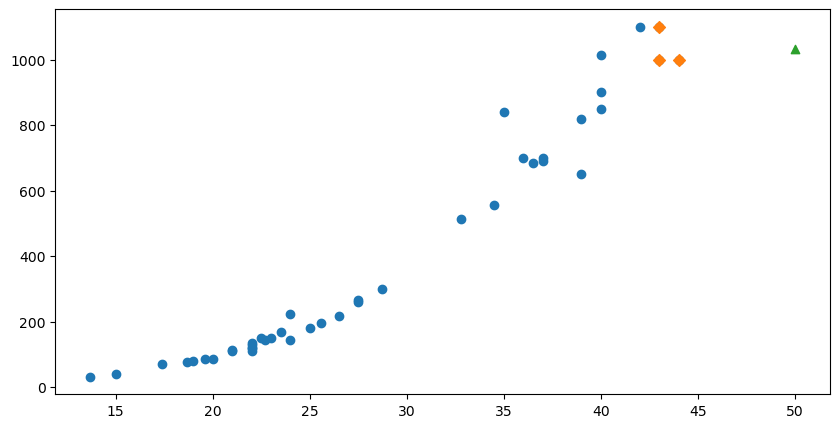

In [24]:
# 50cm인 생선의 이웃을 찾자
distance, indexes = knr.kneighbors([[50]])

# 훈련세트의 산점도
plt.figure(figsize= (10, 5))
plt.scatter(train_input, train_target)

# 이웃을 그리자
plt.scatter(
    train_input[indexes],
    train_target[indexes],
    marker='D'
)

# 50cm 생선 데이터
plt.scatter(
    50,
    1033,
    marker='^'
)

plt.show()

In [25]:
# 이웃들의 평균값 계산
np.mean(train_target[indexes])

np.float64(1033.3333333333333)

#### 길이가 100cm인 생선의 무게 예측

In [26]:
# 길이가 100cm인 생선의 무게
knr.predict([[100]])

array([1033.33333333])

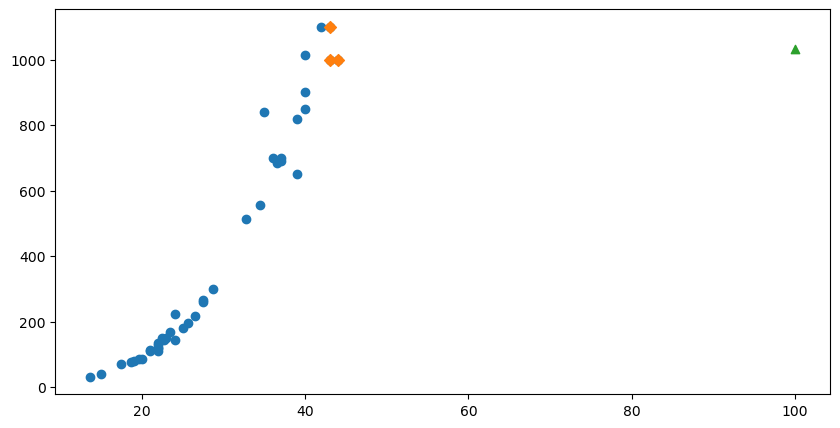

In [27]:
# 시각화로 확인
# 100cm인 생선의 이웃을 찾자
distance, indexes = knr.kneighbors([[100]])

# 훈련세트의 산점도
plt.figure(figsize= (10, 5))
plt.scatter(train_input, train_target)

# 이웃을 그리자
plt.scatter(
    train_input[indexes],
    train_target[indexes],
    marker='D'
)

# 100cm 생선 데이터
plt.scatter(
    100,
    1033,
    marker='^'
)

plt.show()

> kNN Regression은 주변 이웃의 값들의 평균을 구하는 것이므로 학습한               
  데이터의 범위를 벗어나게 되면 사용할 수 없다.

----
#### 선형 회귀(Linear Regression)
  직선이나 곡선의 함수식(방정식: Y=aX+b)을 이용하여 구하는 방식으로        
  로지스틱 회귀분석이나 인공신경망의 기초가 되었다.

In [28]:
from sklearn.linear_model import LinearRegression

In [32]:
lr = LinearRegression()
lr.fit(train_input, train_target)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [33]:
lr.predict([[50]])

array([1241.83860323])

In [34]:
# y=ax+b에서 기울기와 절편 출력(Deep Learning에서는 weight, Bias로 불림)
print(lr.coef_, lr.intercept_)

[39.01714496] -709.0186449535477


In [35]:
39.01714496 * 50 -709.0186449535477

1241.8386030464526

### 산점도 그려보기

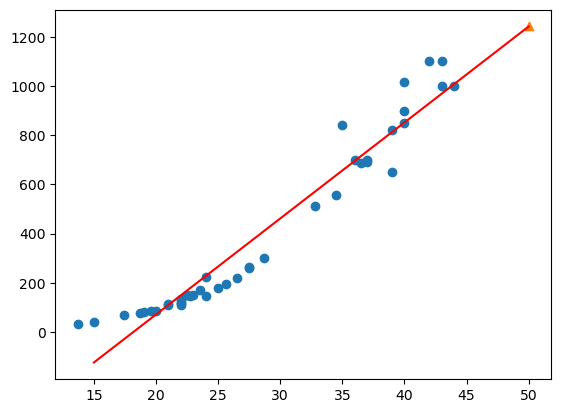

In [38]:
plt.Figure(figsize=(10,5))
plt.scatter(train_input, train_target)
#길이가 15 ~ 50까지 1차방정식 그래프
plt.plot(
    [15, 50],
    [15*lr.coef_+ lr.intercept_, 50*lr.coef_+ lr.intercept_],
    c='red'
)
# 50cm 생선
plt.scatter(50, 1241.8, marker='^')

plt.show()

> 산점도의 회귀선을 보니 길이가 작아지면 무게가 음수가 발생할 수 있다.             
> 절편이 음수이다.

----
#### 특성공학(Feature Engineering)
#### 다항회귀
y= aX+b -> y=aX^2+ bX + c
#### 다중회귀
y= aX1 + aX2 .... + b

In [60]:
# Feature를 제곱한 Column을 생성하여 기존의 Column에 붙인다.
train_poly = np.column_stack((train_input**2, train_input))
test_poly = np.column_stack((test_input**2, test_input))

In [61]:
# 크기 확인
print(train_poly.shape, test_poly.shape)

(42, 2) (14, 2)


In [ ]:
train_poly

In [42]:
# Model 생성
lr = LinearRegression()

In [56]:
# 훈련
lr.fit(train_poly, train_target)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [57]:
# 50cm 생성의 무게 예측
lr.predict([[50**2, 50]])

array([1573.98423528])

In [58]:
# 기울기와 절편
print(lr.coef_, lr.intercept_)

[  1.01433211 -21.55792498] 116.0502107827827


In [46]:
1.01433211* 50**2 + -21.55792498 * 50 + 116.0502107827827

1573.9842367827825

### 산점도 그리기

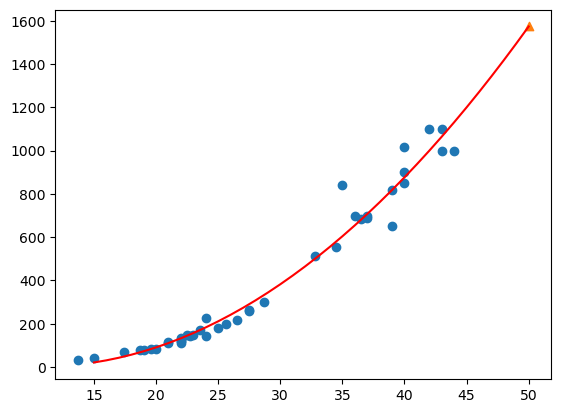

In [67]:
# 훈련세트의 산점도
plt.Figure(figsize=(10,5))
plt.scatter(train_input, train_target)

#길이가 15 ~ 50까지 2차방정식 그래프
point = np.arange(15, 51)
plt.plot(
    point,
    lr.coef_[0]*point**2 + lr.coef_[1] * point + lr.intercept_,
    c='red'
)
# 50cm 생선
plt.scatter(50, 1574, marker='^')

plt.show()